# 图表反演

In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

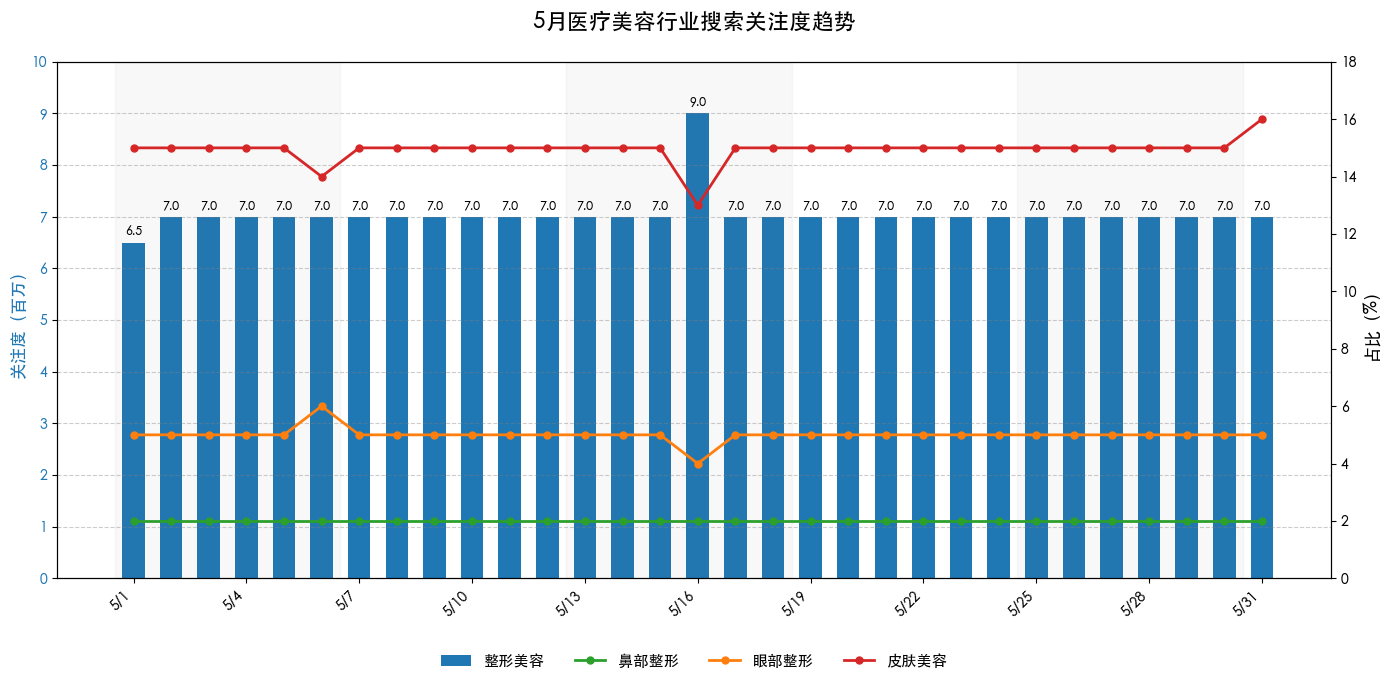

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 生成完整的5月日期（1-31日）
dates = [f"5/{i}" for i in range(1, 32)]
x = np.arange(len(dates))  # 用于横坐标定位

# 整形美容关注度数据（左侧纵轴，单位：百万）
plastic_surgery = [
    6.5, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0,
    7.0, 7.0, 7.0, 7.0, 9.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0,
    7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0
]

# 鼻部整形占比数据（右侧纵轴，单位：%）
nose_plastic = [
    2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0
]

# 眼部整形占比数据（右侧纵轴，单位：%）
eye_plastic = [
    5.0, 5.0, 5.0, 5.0, 5.0, 6.0, 5.0, 5.0, 5.0, 5.0, 5.0,
    5.0, 5.0, 5.0, 5.0, 4.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0,
    5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0
]

# 皮肤美容占比数据（右侧纵轴，单位：%）
skin_care = [
    15.0, 15.0, 15.0, 15.0, 15.0, 14.0, 15.0, 15.0, 15.0, 15.0, 15.0,
    15.0, 15.0, 15.0, 15.0, 13.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0,
    15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 16.0
]

# 创建画布和双轴
fig, ax1 = plt.subplots(figsize=(14, 7))  # 增大画布尺寸
ax2 = ax1.twinx()

# 绘制整形美容柱状图（左轴）
bar_width = 0.6
bars = ax1.bar(
    x,
    plastic_surgery,
    color="#1f77b4",  # 专业蓝色
    width=bar_width,
    label="整形美容"
)
ax1.set_ylabel("关注度（百万）", color="#1f77b4", fontsize=12, fontweight="bold")
ax1.set_ylim(0, 10)
ax1.set_yticks(np.arange(0, 11, 1))
ax1.tick_params(axis="y", labelcolor="#1f77b4", labelsize=10)

# 在柱状图顶部添加数值标签
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2., height + 0.1,
        f'{height:.1f}',
        ha='center', va='bottom', fontsize=9
    )

# 绘制鼻部整形折线（右轴）
ax2.plot(
    x,
    nose_plastic,
    color="#2ca02c",  # 专业绿色
    marker="o",
    markersize=5,
    linestyle="-",
    linewidth=2,
    label="鼻部整形"
)

# 绘制眼部整形折线（右轴）
ax2.plot(
    x,
    eye_plastic,
    color="#ff7f0e",  # 专业橙色
    marker="o",
    markersize=5,
    linestyle="-",
    linewidth=2,
    label="眼部整形"
)

# 绘制皮肤美容折线（右轴）
ax2.plot(
    x,
    skin_care,
    color="#d62728",  # 专业红色
    marker="o",
    markersize=5,
    linestyle="-",
    linewidth=2,
    label="皮肤美容"
)
ax2.set_ylabel("占比（%）", color="black", fontsize=12, fontweight="bold")
ax2.set_ylim(0, 18)
ax2.set_yticks(np.arange(0, 20, 2))
ax2.tick_params(axis="y", labelcolor="black", labelsize=10)

# 设置横轴刻度（每3天显示一个刻度，避免过于拥挤）
ax1.set_xticks(x[::3])  # 每隔3天显示一个刻度
ax1.set_xticklabels(dates[::3], fontsize=10, rotation=45, ha="right")  # 旋转45度并右对齐

# 添加网格（仅左轴y方向）
ax1.grid(axis="y", linestyle="--", color="gray", alpha=0.4)

# 合并图例（放置在底部）
lines_ax1, labels_ax1 = ax1.get_legend_handles_labels()
lines_ax2, labels_ax2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines_ax1 + lines_ax2,
    labels_ax1 + labels_ax2,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.2),
    frameon=False,
    fontsize=11
)

# 设置标题
ax1.set_title("5月医疗美容行业搜索关注度趋势", fontsize=16, fontweight="bold", y=1.05)

# 添加背景色区分不同区域
for i in range(0, len(dates), 6):
    if i % 12 == 0:
        ax1.axvspan(i-0.5, i+5.5, alpha=0.05, color='gray')

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()

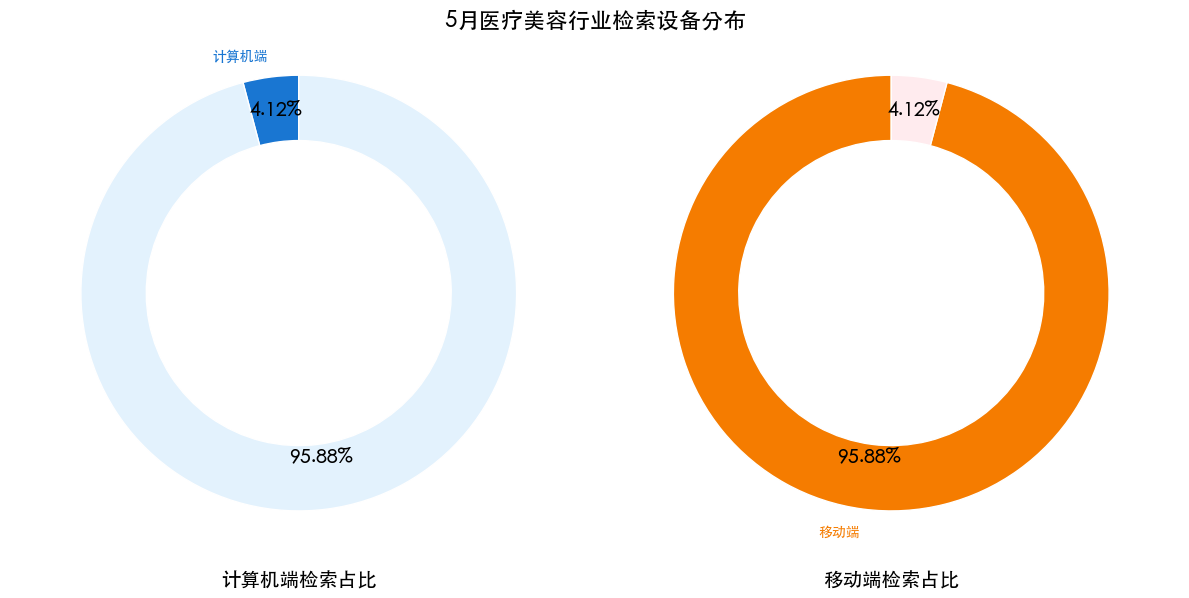

In [3]:
import matplotlib.pyplot as plt

# 数据
sizes = [4.12, 95.88]

# 颜色，更接近原图
computer_colors = ["#1976d2", "#e3f2fd"]  # 计算机端颜色：深蓝色和浅蓝色
mobile_colors = ["#f57c00", "#ffebee"]    # 移动端颜色：橙色和浅橙色

# 创建画布和两个子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.subplots_adjust(top=0.85, bottom=0.15)  # 调整顶部和底部边距

# 绘制计算机端检索占比图（标签颜色调整）
wedges1, texts1, autotexts1 = ax1.pie(
    [sizes[0], 100 - sizes[0]],
    labels=["计算机端", ""],  # 简化标签
    autopct=lambda p: f'{p:.2f}%\n' if p >= 3 else '',
    startangle=90,
    pctdistance=0.8,
    colors=computer_colors,
    wedgeprops=dict(width=0.3, edgecolor='w')
)

# 绘制移动端检索占比图（标签颜色调整）
wedges2, texts2, autotexts2 = ax2.pie(
    [sizes[1], 100 - sizes[1]],
    labels=["移动端", ""],  # 简化标签
    autopct=lambda p: f'{p:.2f}%\n' if p >= 3 else '',
    startangle=90,
    pctdistance=0.8,
    colors=mobile_colors,
    wedgeprops=dict(width=0.3, edgecolor='w')
)

# 设置标签颜色（与对应饼图颜色一致）
for text in texts1:
    text.set_color(computer_colors[0])  # 计算机端标签颜色为深蓝色
for text in texts2:
    text.set_color(mobile_colors[0])    # 移动端标签颜色为深橙色

# 设置百分比文本颜色为黑色
for text in autotexts1 + autotexts2:
    text.set_color('black')
    text.set_fontsize(14)

# 去除坐标轴，使图表为正圆形
ax1.axis('equal')
ax2.axis('equal')

# 设置小标题（在图表下方）
ax1.text(0.5, -0.1, "计算机端检索占比", 
         ha='center', va='center', transform=ax1.transAxes, fontsize=14)
ax2.text(0.5, -0.1, "移动端检索占比", 
         ha='center', va='center', transform=ax2.transAxes, fontsize=14)

# 设置总标题
fig.suptitle("5月医疗美容行业检索设备分布", fontsize=16, fontweight='bold')

plt.tight_layout()  # 调整布局，避免重叠
plt.show()

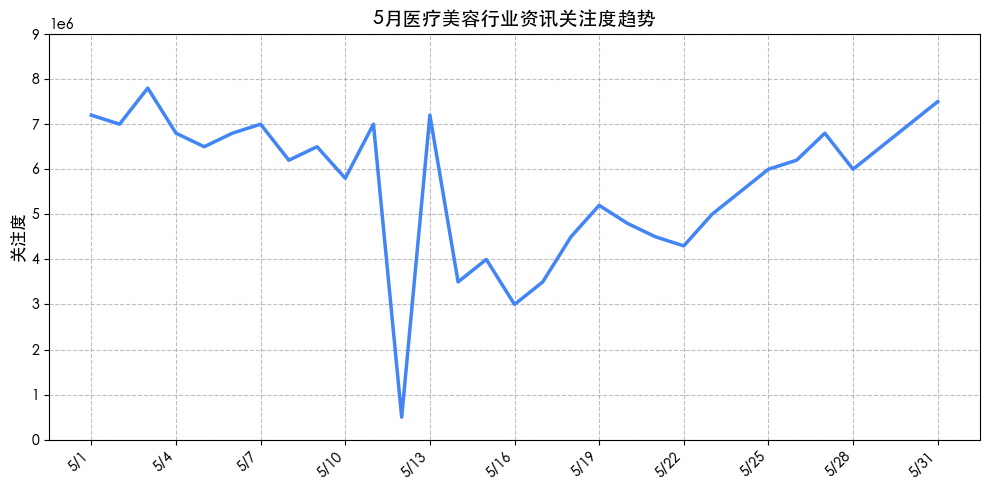

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 使用您提供的精确数据
dates = [f"5/{i}" for i in range(1, 32)]
values = [
    7200000, 7000000, 7800000, 6800000, 6500000, 6800000, 7000000, 6200000, 
    6500000, 5800000, 7000000, 500000, 7200000, 3500000, 4000000, 3000000, 
    3500000, 4500000, 5200000, 4800000, 4500000, 4300000, 5000000, 5500000, 
    6000000, 6200000, 6800000, 6000000, 6500000, 7000000, 7500000
]

# 创建画布
fig, ax = plt.subplots(figsize=(10, 5))  # 稍微加宽画布以容纳更多数据点

# 绘制折线图，颜色和线宽匹配原图
ax.plot(dates, values, color="#4285f4", linewidth=2.5)

# 设置标题
ax.set_title("5月医疗美容行业资讯关注度趋势", fontsize=14, fontweight="bold")

# 设置纵轴（关注度）
ax.set_ylabel("关注度", fontsize=12)
ax.set_ylim(0, 9000000)  # 匹配原图纵轴范围
ax.set_yticks(np.arange(0, 10000000, 1000000))  # 纵轴刻度间隔100万

# 设置横轴（日期）- 每3天显示一个刻度
ax.set_xticks(np.arange(0, len(dates), 3))  # 每隔3天显示一个刻度
ax.set_xticklabels([dates[i] for i in range(0, len(dates), 3)], rotation=45, ha="right")  # 旋转45度避免重叠

# 添加网格线
ax.grid(linestyle="--", color="gray", alpha=0.5)

# 优化布局
plt.tight_layout()

# 显示图表
plt.show()

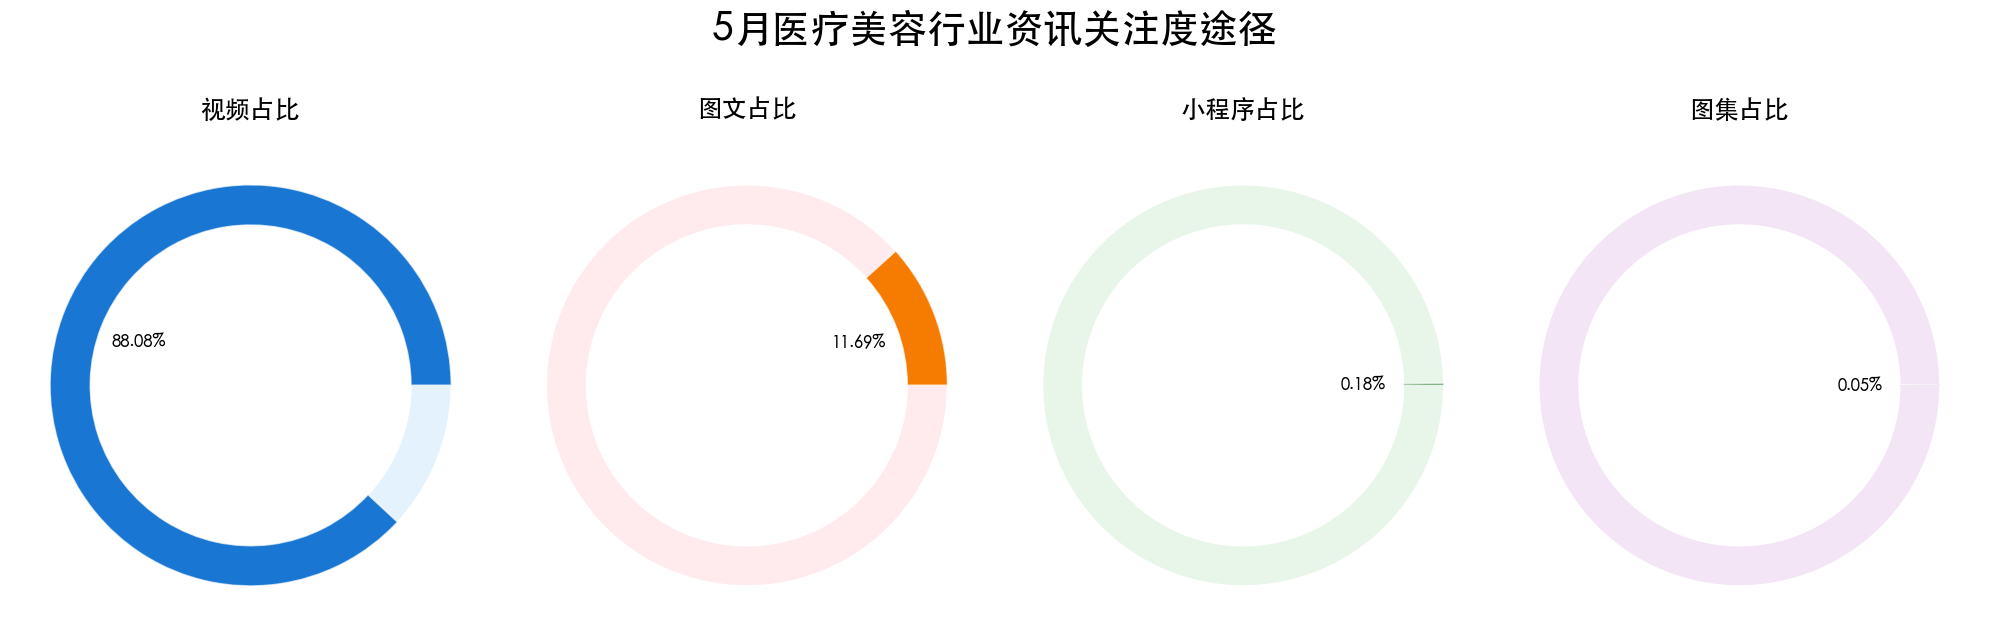

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Wedge
from matplotlib.collections import PatchCollection
import numpy as np

# 数据
sizes = [88.08, 11.69, 0.18, 0.05]
labels = ["视频占比", "图文占比", "小程序占比", "图集占比"]

# 自定义颜色方案
colors = [
    ["#1976d2", "#e3f2fd"],  # 视频占比：深蓝色和浅蓝色
    ["#f57c00", "#ffebee"],  # 图文占比：橙色和浅橙色
    ["#388e3c", "#e8f5e9"],  # 小程序占比：绿色和浅绿色
    ["#7b1fa2", "#f3e5f5"]   # 图集占比：紫色和浅紫色
]

# 创建3D效果
fig = plt.figure(figsize=(20, 10))
fig.subplots_adjust(top=0.85, bottom=0.15, wspace=0.3)

# 创建4个子图
axes = []
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1, aspect='equal')
    axes.append(ax)

# 绘制3D饼图
for i, ax in enumerate(axes):
    # 设置颜色
    chart_colors = [colors[i][0], colors[i][1]]
    
    # 计算角度
    theta1 = 0
    theta2 = 360 * sizes[i]/100
    
    # 创建3D效果 - 绘制多层扇形
    for height in [0, 0.1, 0.2]:
        if sizes[i] < 5:  # 小数值部分加厚突出
            height_factor = 0.3
        else:
            height_factor = 0.1
            
        # 主扇形
        wedge = Wedge((0,0), 1, theta1, theta2, width=0.2, 
                     facecolor=chart_colors[0], edgecolor='w', linewidth=1)
        ax.add_patch(wedge)
        
        # 底部扇形（浅色部分）
        wedge_bottom = Wedge((0,0), 1, theta2, 360, width=0.2,
                           facecolor=chart_colors[1], edgecolor='w', linewidth=1)
        ax.add_patch(wedge_bottom)
        
        # 添加3D边缘效果
        if height > 0:
            edge = Wedge((0,0), 1, theta1, theta2, width=0.2,
                        facecolor=chart_colors[0], alpha=0.3)
            ax.add_patch(edge)
    
    # 设置标题
    ax.set_title(labels[i], fontsize=18, pad=20)
    
    # 添加百分比标签
    if sizes[i] >= 0.01:  # 只显示大于0.1%的标签
        angle = theta1 + (theta2 - theta1)/2
        x = 0.6 * np.cos(np.deg2rad(angle))
        y = 0.6 * np.sin(np.deg2rad(angle))
        ax.text(x, y, f"{sizes[i]:.2f}%", 
                ha='center', va='center', fontsize=12)
    
    # 设置坐标范围
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.axis('off')

# 设置总标题
fig.suptitle("5月医疗美容行业资讯关注度途径", fontsize=28, fontweight='bold', y=0.85)

plt.tight_layout()
plt.show()
